In [2]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns

RANDOM_STATE = 42
MODEL_NAME = "distilbert-base-uncased"

In [3]:
train_df = pd.read_csv('D:\\ITI\\9 Months Training AI\\NLP\\Final Project\\datasets\\Emotion Classifier\\train.csv')
val_df = pd.read_csv('D:\\ITI\\9 Months Training AI\\NLP\\Final Project\\datasets\\Emotion Classifier\\validation.csv')
test_df = pd.read_csv('D:\\ITI\\9 Months Training AI\\NLP\\Final Project\\datasets\\Emotion Classifier\\test.csv')


In [4]:
train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 16000 entries, 0 to 15999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   text    16000 non-null  str  
 1   label   16000 non-null  int64
dtypes: int64(1), str(1)
memory usage: 1.7 MB


In [5]:
train_df

,text,label
0,i didnt feel humiliated,0
1,i can go from feeling so hopeless to so damned...,0
2,im grabbing a minute to post i feel greedy wrong,3
3,i am ever feeling nostalgic about the fireplac...,2
4,i am feeling grouchy,3
...,...,...
15995,i just had a very brief time in the beanbag an...,0
15996,i am now turning and i feel pathetic that i am...,0
15997,i feel strong and good overall,1
15998,i feel like this was such a rude comment and i...,3


In [6]:
train_df['label'].value_counts()

label
1    5362
0    4666
3    2159
4    1937
2    1304
5     572
Name: count, dtype: int64

In [7]:
#check for duplicates in the training set
print("Number of duplicate rows in the training set:", train_df.duplicated().sum())

Number of duplicate rows in the training set: 1


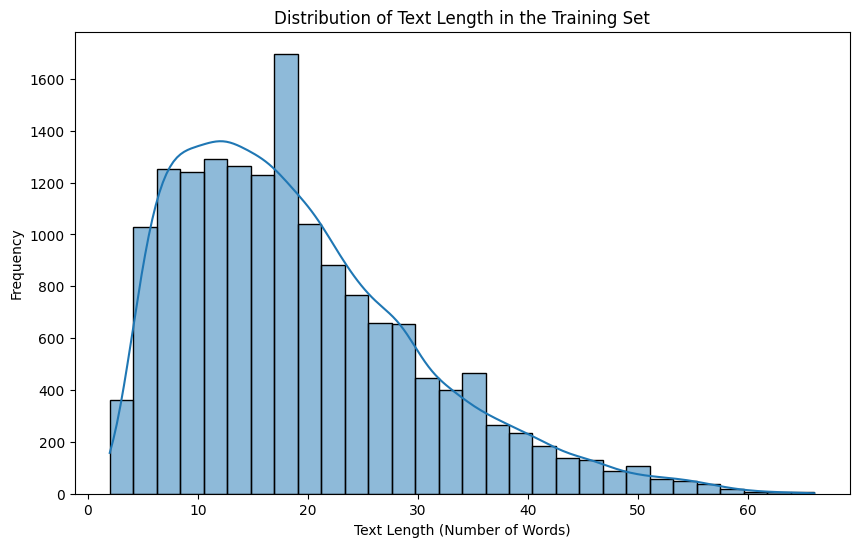

In [8]:
#draw histogram of the length of text in the training set
train_df['text_length'] = train_df['text'].apply(lambda x: len(x.split()))
plt.figure(figsize=(10, 6))
sns.histplot(train_df['text_length'], bins=30, kde=True)
plt.title('Distribution of Text Length in the Training Set')
plt.xlabel('Text Length (Number of Words)')
plt.ylabel('Frequency')
plt.show()


In [9]:
mapping = {0: 'sadness', 1: 'joy', 2: 'love', 3: 'anger', 4: 'fear', 5: 'surprise'}

In [10]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn

from torch.utils.data import Dataset, DataLoader

from collections import Counter

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)

In [11]:
import sys
print(sys.executable)

c:\Users\Admin\AppData\Local\Programs\Python\Python311\python.exe


In [12]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn

from torch.utils.data import Dataset, DataLoader

from collections import Counter

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)

In [13]:
TRAIN_PATH = "D:\\ITI\\9 Months Training AI\\NLP\\Final Project\\datasets\\Emotion Classifier\\train.csv"
VAL_PATH   = "D:\\ITI\\9 Months Training AI\\NLP\\Final Project\\datasets\\Emotion Classifier\\validation.csv"
TEST_PATH  = "D:\\ITI\\9 Months Training AI\\NLP\\Final Project\\datasets\\Emotion Classifier\\test.csv"

MAX_LEN = 64
BATCH_SIZE = 32

EMBED_DIM = 128
HIDDEN_DIM = 256
NUM_LAYERS = 2
DROPOUT = 0.3

NUM_CLASSES = 6

EPOCHS = 10
LEARNING_RATE = 1e-3

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [14]:
id2label = {
    0: "sadness",
    1: "joy",
    2: "love",
    3: "anger",
    4: "fear",
    5: "surprise"
}

In [15]:
train_df = pd.read_csv(TRAIN_PATH)
val_df   = pd.read_csv(VAL_PATH)
test_df  = pd.read_csv(TEST_PATH)

In [16]:
def tokenize(text):
    return text.lower().split()

In [17]:
counter = Counter()

for text in train_df["text"]:
    counter.update(tokenize(text))

vocab = {"<PAD>": 0, "<UNK>": 1}

for word in counter:
    vocab[word] = len(vocab)

PAD_IDX = vocab["<PAD>"]
UNK_IDX = vocab["<UNK>"]
VOCAB_SIZE = len(vocab)

print("Vocab size:", VOCAB_SIZE)

Vocab size: 15214


In [18]:
def encode(text):
    tokens = tokenize(text)

    ids = [vocab.get(t, UNK_IDX) for t in tokens]
    ids = ids[:MAX_LEN]

    if len(ids) < MAX_LEN:
        ids += [PAD_IDX] * (MAX_LEN - len(ids))

    return ids

In [19]:
class EmotionDataset(Dataset):

    def __init__(self, df):
        self.texts = df["text"].tolist()
        self.labels = df["label"].tolist()

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):

        x = encode(self.texts[idx])
        y = self.labels[idx]

        return (
            torch.tensor(x, dtype=torch.long),
            torch.tensor(y, dtype=torch.long)
        )

In [20]:
train_loader = DataLoader(EmotionDataset(train_df), batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(EmotionDataset(val_df), batch_size=BATCH_SIZE)
test_loader   = DataLoader(EmotionDataset(test_df), batch_size=BATCH_SIZE)

In [21]:
class LSTMClassifier(nn.Module):

    def __init__(self):
        super().__init__()

        self.embedding = nn.Embedding(VOCAB_SIZE, EMBED_DIM, padding_idx=PAD_IDX)

        self.lstm = nn.LSTM(
            input_size=EMBED_DIM,
            hidden_size=HIDDEN_DIM,
            num_layers=NUM_LAYERS,
            batch_first=True,
            dropout=DROPOUT,
            bidirectional=True
        )

        self.dropout = nn.Dropout(DROPOUT)

        self.fc = nn.Linear(HIDDEN_DIM * 2, NUM_CLASSES)

    def forward(self, x):

        x = self.embedding(x)

        _, (hidden, _) = self.lstm(x)

        # concat forward + backward
        hidden = torch.cat((hidden[-2], hidden[-1]), dim=1)

        x = self.dropout(hidden)

        return self.fc(x)

In [22]:
model = LSTMClassifier().to(DEVICE)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

In [23]:
for epoch in range(EPOCHS):

    # ======================
    # TRAINING
    # ======================
    model.train()
    train_loss = 0

    for x, y in train_loader:

        x = x.to(DEVICE)
        y = y.to(DEVICE)

        optimizer.zero_grad()

        logits = model(x)

        loss = criterion(logits, y)

        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    avg_train_loss = train_loss / len(train_loader)

    # ======================
    # VALIDATION
    # ======================
    model.eval()

    val_loss = 0
    preds_all = []
    targets_all = []

    with torch.no_grad():

        for x, y in val_loader:

            x = x.to(DEVICE)
            y = y.to(DEVICE)

            logits = model(x)

            loss = criterion(logits, y)
            val_loss += loss.item()

            preds = logits.argmax(dim=1)

            preds_all.extend(preds.cpu().numpy())
            targets_all.extend(y.cpu().numpy())

    avg_val_loss = val_loss / len(val_loader)

    acc = accuracy_score(targets_all, preds_all)
    f1 = f1_score(targets_all, preds_all, average="weighted")

    print(
        f"Epoch {epoch+1}/{EPOCHS} | "
        f"Train Loss={avg_train_loss:.4f} | "
        f"Val Loss={avg_val_loss:.4f} | "
        f"Acc={acc:.4f} | "
        f"F1={f1:.4f}"
    )

Epoch 1/10 | Train Loss=1.3062 | Val Loss=0.7928 | Acc=0.7235 | F1=0.6945
Epoch 2/10 | Train Loss=0.4988 | Val Loss=0.3262 | Acc=0.8835 | F1=0.8813
Epoch 3/10 | Train Loss=0.2107 | Val Loss=0.2551 | Acc=0.9045 | F1=0.9034
Epoch 4/10 | Train Loss=0.1360 | Val Loss=0.2467 | Acc=0.9115 | F1=0.9114
Epoch 5/10 | Train Loss=0.0948 | Val Loss=0.2389 | Acc=0.9135 | F1=0.9133
Epoch 6/10 | Train Loss=0.0769 | Val Loss=0.2294 | Acc=0.9200 | F1=0.9200
Epoch 7/10 | Train Loss=0.0680 | Val Loss=0.2401 | Acc=0.9165 | F1=0.9162
Epoch 8/10 | Train Loss=0.0572 | Val Loss=0.2411 | Acc=0.9180 | F1=0.9179
Epoch 9/10 | Train Loss=0.0404 | Val Loss=0.3198 | Acc=0.9080 | F1=0.9076
Epoch 10/10 | Train Loss=0.0391 | Val Loss=0.3401 | Acc=0.9140 | F1=0.9138


In [24]:
model.eval()

preds_all = []
targets_all = []

with torch.no_grad():

    for x, y in test_loader:

        x = x.to(DEVICE)

        logits = model(x)

        preds = logits.argmax(dim=1)

        preds_all.extend(preds.cpu().numpy())
        targets_all.extend(y.numpy())

print("\nTEST RESULTS")
print("Accuracy:", accuracy_score(targets_all, preds_all))
print("F1:", f1_score(targets_all, preds_all, average="weighted"))

print("\nClassification Report:")
print(classification_report(targets_all, preds_all, target_names=[id2label[i] for i in range(NUM_CLASSES)]))

print("\nConfusion Matrix:")
print(confusion_matrix(targets_all, preds_all))


TEST RESULTS
Accuracy: 0.909
F1: 0.9084973988953053

Classification Report:
              precision    recall  f1-score   support

     sadness       0.91      0.97      0.94       581
         joy       0.94      0.91      0.93       695
        love       0.78      0.81      0.79       159
       anger       0.93      0.89      0.91       275
        fear       0.88      0.89      0.89       224
    surprise       0.83      0.68      0.75        66

    accuracy                           0.91      2000
   macro avg       0.88      0.86      0.87      2000
weighted avg       0.91      0.91      0.91      2000


Confusion Matrix:
[[566   6   0   6   3   0]
 [ 13 635  37   4   1   5]
 [  6  23 128   2   0   0]
 [ 20   4   0 244   7   0]
 [ 11   3   0   6 200   4]
 [  3   2   0   0  16  45]]


In [25]:
torch.save({
    "model_state_dict": model.state_dict(),
    "vocab": vocab,
    "config": {
        "vocab_size": len(vocab),
        "embed_dim": 128,
        "hidden_dim": 256,
        "num_layers": 2,
        "num_classes": 6,
        "pad_idx": vocab["<PAD>"]
    }
}, "lstm_emotion_classifier.pth")

print("Model Saved")

Model Saved
